In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import dkistpkg_ct as DKISTanalysis

In [3]:
base = '/Volumes/ViSP_External/pid_2_11/'
caII_folder = 'XVOUZY/'
hbeta_folder = 'JPYGIO/'

caII_processed = '/Volumes/ViSP_External/CaII_11Aug_2024_Cclass_newcalib.npz'
hbeta_processed =  '/Volumes/ViSP_External/Hbeta_11Aug2024_Cclass_newcalib.npz'

In [4]:
dir_list_CaII = DKISTanalysis.pathdef(base,caII_folder) 
dir_list_Hbeta = DKISTanalysis.pathdef(base,hbeta_folder) 

In [5]:
startind = 2548
nslit = 91

In [6]:
goodscan_caII = dir_list_CaII[startind:startind+nslit]
goodscan_hbeta = dir_list_Hbeta[startind:startind+nslit]

In [7]:
#function to get co-ordinates along slit
firststep = fits.open(base+caII_folder+goodscan_caII[0])

center = firststep[1].header['CRVAL1']
dy = firststep[1].header['CDELT1']
center_unit = firststep[1].header['CUNIT1']
n1 = firststep[1].header['NAXIS1']


yarr_caII = np.arange(center+(n1*dy/2),center-(n1*dy/2),-dy)

#function to get co-ordinates along slit
firststep = fits.open(base+hbeta_folder+goodscan_hbeta[0])

center = firststep[1].header['CRVAL1']
dy = firststep[1].header['CDELT1']
center_unit = firststep[1].header['CUNIT1']
n1 = firststep[1].header['NAXIS1']

yarr_hbeta = np.arange(center+(n1*dy/2),center-(n1*dy/2),-dy)

In [8]:
step = fits.open(base+caII_folder+goodscan_caII[0])
center = firststep[1].header['CRVAL3']
dx = firststep[1].header['CDELT3']
center_unit = firststep[1].header['CUNIT3']
n1 = firststep[1].header['NAXIS3']

In [9]:
center

763.4143104254169

In [10]:
#get coordinates of slit - read each file in, individually
#in this case assumes 'x' coordinate is just the center of the scan, but this not really the case, slit is at angle

#caII

xarr_caII_centers = []

for i in range(len(goodscan_caII)):
    step = fits.open(base+caII_folder+goodscan_caII[i])
    center = firststep[1].header['CRVAL3']
    dx = firststep[1].header['CDELT3']
    center_unit = firststep[1].header['CUNIT3']
    n1 = firststep[1].header['NAXIS3']

    xarr_caII_centers.append(center)

#hbeta

xarr_hbeta_centers = []

for i in range(len(goodscan_hbeta)):
    step = fits.open(base+hbeta_folder+goodscan_hbeta[i])
    center = firststep[1].header['CRVAL3']
    dx = firststep[1].header['CDELT3']
    center_unit = firststep[1].header['CUNIT3']
    n1 = firststep[1].header['NAXIS3']

    xarr_hbeta_centers.append(center)



In [11]:
#they're all the same - just takes the center value for the scan, I guess. populate with just one file

#caII

step = fits.open(base+caII_folder+goodscan_caII[0])
center = firststep[1].header['CRVAL3']
dx = firststep[1].header['CDELT3']
center_unit = firststep[1].header['CUNIT3']
n3 = 91

xarr_caII = np.arange(center+(n3*dx/2),center-(n3*dx/2),-dx)

#hbeta

step = fits.open(base+hbeta_folder+goodscan_hbeta[0])
center = firststep[1].header['CRVAL3']
dx = firststep[1].header['CDELT3']
center_unit = firststep[1].header['CUNIT3']
n3 = 91

xarr_hbeta = np.arange(center+(n3*dx/2),center-(n3*dx/2),-dx)

In [13]:
image_data_arr_arrhbeta, rasterposhbeta, timeshbeta = \
        DKISTanalysis.multistepprocess(base,hbeta_folder,dir_list_Hbeta,startstep=startind,div=1,endstep=startind+nslit+1)


2548
2549
2550
2551
2552
2553
2554
2555
2556
2557
2558
2559
2560
2561
2562
2563
2564
2565
2566
2567
2568
2569
2570
2571
2572
2573
2574
2575
2576
2577
2578
2579
2580
2581
2582
2583
2584
2585
2586
2587
2588
2589
2590
2591
2592
2593
2594
2595
2596
2597
2598
2599
2600
2601
2602
2603
2604
2605
2606
2607
2608
2609
2610
2611
2612
2613
2614
2615
2616
2617
2618
2619
2620
2621
2622
2623
2624
2625
2626
2627
2628
2629
2630
2631
2632
2633
2634
2635
2636
2637
2638


In [14]:
image_data_arr_arrcaIIH, rasterposcaIIH, timescaIIH = \
        DKISTanalysis.multistepprocess(base,caII_folder,dir_list_CaII,startstep=startind,div=1,endstep=startind+nslit+1)


2548
2549
2550
2551
2552
2553
2554
2555
2556
2557
2558
2559
2560
2561
2562
2563
2564
2565
2566
2567
2568
2569
2570
2571
2572
2573
2574
2575
2576
2577
2578
2579
2580
2581
2582
2583
2584
2585
2586
2587
2588
2589
2590
2591
2592
2593
2594
2595
2596
2597
2598
2599
2600
2601
2602
2603
2604
2605
2606
2607
2608
2609
2610
2611
2612
2613
2614
2615
2616
2617
2618
2619
2620
2621
2622
2623
2624
2625
2626
2627
2628
2629
2630
2631
2632
2633
2634
2635
2636
2637
2638


In [15]:
XcaIIH,YcaIIH = np.meshgrid(xarr_caII,yarr_caII)
Xhbeta,Yhbeta = np.meshgrid(xarr_caII,yarr_hbeta)

In [25]:
meanCaIIH = np.mean(image_data_arr_arrcaIIH[:,500:600,:],1)
meanhbeta = np.mean(image_data_arr_arrhbeta[:,300:700,:-1],1)

In [26]:
print(np.shape(XcaIIH))
print(np.shape(YcaIIH))
print(np.shape(meanCaIIH))

(2557, 92)
(2557, 92)
(91, 2556)


(-262.0, -259.0)

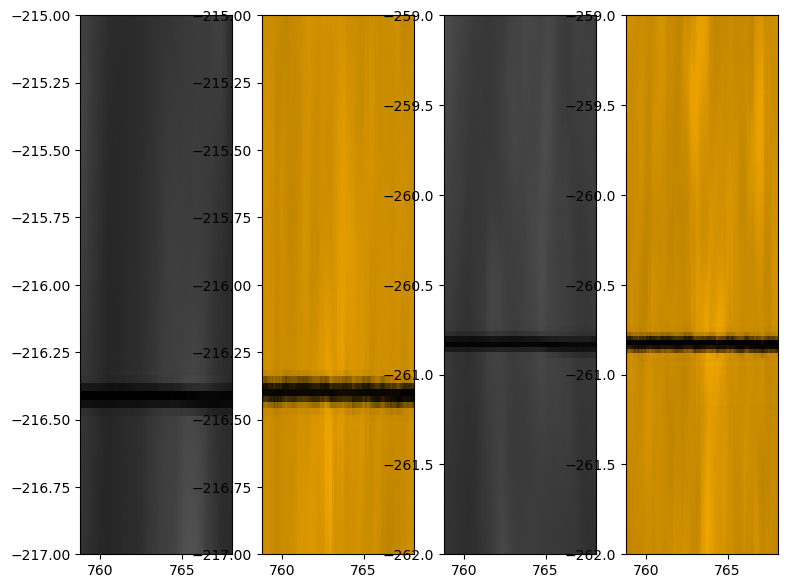

In [55]:

fig, ax = plt.subplots(1,4,dpi=100,figsize=(9,7))

shiftaxis = 3.325-(np.arange(2557)*0.00035)

ax.flatten()[0].pcolormesh(xarr_caII,yarr_caII-shiftaxis,np.transpose(meanCaIIH),cmap='grey')
ax.flatten()[1].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(meanhbeta),cmap='sdoaia171')

ax.flatten()[2].pcolormesh(xarr_caII,yarr_caII-shiftaxis,np.transpose(meanCaIIH),cmap='grey')
ax.flatten()[3].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(meanhbeta),cmap='sdoaia171')

ax.flatten()[0].set_ylim([-217,-215])
ax.flatten()[1].set_ylim([-217,-215])

ax.flatten()[2].set_ylim([-262,-259])
ax.flatten()[3].set_ylim([-262,-259])



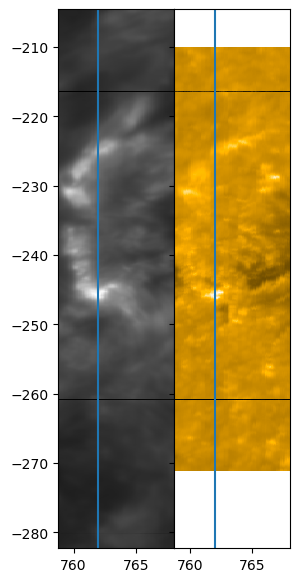

In [56]:
fig, ax = plt.subplots(1,2, sharey=True,dpi=100,figsize=(3,7))
ax.flatten()[0].pcolormesh(xarr_caII,yarr_caII-shiftaxis,np.transpose(meanCaIIH),cmap='grey')
ax.flatten()[1].pcolormesh(xarr_hbeta,yarr_hbeta,np.transpose(meanhbeta),cmap='sdoaia171')


fig.subplots_adjust(wspace=0)
fig.align_ylabels()

#ax.flatten()[0].set_ylim([-262,-214])
#ax.flatten()[1].set_ylim([-262,-214])


vline = 762
ax.flatten()[0].axvline(vline)
ax.flatten()[1].axvline(vline)

In [57]:
yarr_caII_final = yarr_caII-shiftaxis

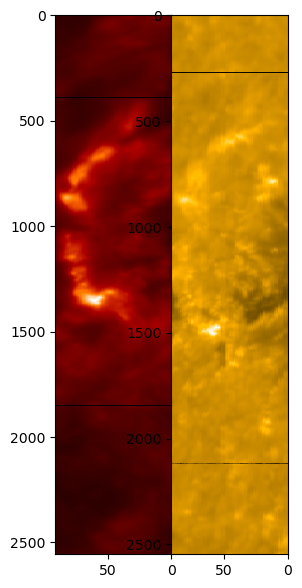

In [58]:
#other
fig, ax = plt.subplots(1,2, dpi=100,figsize=(3,7))
ax.flatten()[0].pcolormesh(np.transpose(meanCaIIH),cmap='sdoaia304')
ax.flatten()[1].pcolormesh(np.transpose(meanhbeta),cmap='sdoaia171')


fig.subplots_adjust(wspace=0)

ax.flatten()[0].invert_xaxis()
ax.flatten()[0].invert_yaxis()

ax.flatten()[1].invert_xaxis()
ax.flatten()[1].invert_yaxis()




In [59]:
outfile = '/Users/coletamburri/Desktop/ViSPcoords_newcalib.npz'

np.savez(outfile,xarr_caII=xarr_caII,yarr_caII=yarr_caII_final,xarr_hbeta=xarr_hbeta,yarr_hbeta=yarr_hbeta)

In [355]:
yarr_caII[1315]

np.float64(-241.68503370382314)

In [112]:
len(yarr_caII)

2548

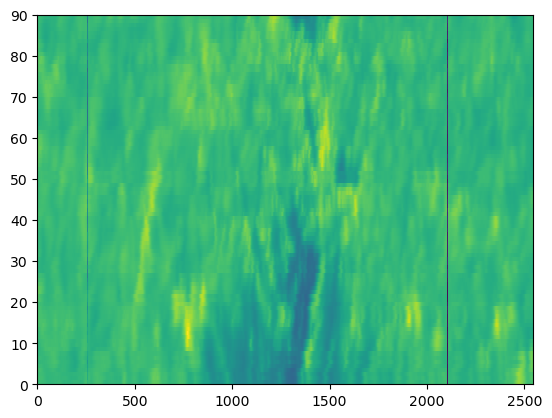

In [104]:
plt.pcolormesh(meanCaIIH)